In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import timm
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
from sympy.tensor import tensor
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import random_split, TensorDataset
import os

In [2]:
"""
Create synthetic "anomalies" 
Returns: The same `hists` tensor, modified in place, with synthetic
anomalies added.
"""
def shift_x_and_add5(hists, plus=1,precent=1):
  for i in range(len(hists)):
    if i%100==0:
      print("in",i)
    hist=hists[i,0]
    cols = torch.where(torch.any(hists[i,0] != 0, axis=0))[0]
    first_from_end = cols[-1]+1
    width = max(int(precent * first_from_end) + 1, 1)
    pad_amt = max(214 - width, 0)
    hist_cp_part = np.pad(np.copy(hists[i, 0, :, :width]),((0, 0), (0, pad_amt)),mode='constant',constant_values=0)
    shifted = np.zeros_like(hist)
    for j in range(plus):
      shift = np.random.randint(10, 105)
      shifted =shifted+ np.roll(hist_cp_part, shift=shift, axis=1)
    hists[i,0]=hist+shifted
  return hists

In [3]:
"""
Run a batch of images through a pretrained model to extract
deep feature embeddings.
Returns:
A NumPy array of shape (N, feature_dim) containing the extracted
feature vector for each input sample.
"""
def feture_extract(m, X, batch=32):
    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    m = m.to(device)
    m.eval()

    loader = DataLoader(
        TensorDataset(X),
        batch_size=batch,
        shuffle=False,
    )

    features = []

    with torch.no_grad():
        for (x,) in tqdm(loader, desc="Extracting features"):
            x = x.to(device)
            features.append(m(x))

    # Move concatenated output back to CPU before converting to NumPy
    return torch.cat(features, dim=0).cpu().numpy()

In [4]:
# MobileNetV4 model:
#m = timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k', pretrained=True, num_classes=0,in_chans=1)
# DINOv3 ViT model:
m = timm.create_model('timm/vit_large_patch16_dinov3.lvd1689m', pretrained=True, num_classes=0,in_chans=1)


model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

In [5]:
timm.data.resolve_model_data_config(m)

{'input_size': (3, 256, 256),
 'interpolation': 'bicubic',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'crop_pct': 1.0,
 'crop_mode': 'center'}

In [6]:
# "bot" data: treated as the "normal" class the One-Class SVM will learn.
path_all_bot=r"/kaggle/input/datasets/nachmanrog/yt-bot/yt_all.npy"
#"human/agent" data: the population we want to inspect after
path_all_human_or_agent=r"/kaggle/input/datasets/nachmanrog/yt-human/yt_human_all.npy"

m.eval()

data=np.load(path_all_bot)# "bot" data: treated as the "normal" class the One-Class SVM will learn.
print("number of FlowPics in train data from bot browsing: ",len(data))
rng = np.random.default_rng()
rng.shuffle(data)
data_h_a=np.load(path_all_human_or_agent)#"human/agent" data: the population we want to inspect after
print("number of FlowPics in data from human/agent browsing: ",len(data_h_a))


# Train/test split of the "bot" (normal) data
train_size = int(0.9 * len(data))
test_size = int( len(data))-train_size

generator = torch.Generator()
train_set, test_set = random_split(
    data,
    [train_size, test_size],
    generator=generator
)


number of FlowPics in train data from bot browsing:  11277
number of FlowPics in data from human/agent browsing:  725


In [7]:
# Convert to float tensors and add a channel dimension (N, 1, H, W) 
X_train = torch.from_numpy(np.copy(train_set)).unsqueeze(1).float()
X_test = torch.from_numpy(np.copy(test_set)).unsqueeze(1).float()
# Build a synthetic "anomaly" version of the test set by shifting/adding
X_test_mod =shift_x_and_add5( torch.from_numpy(np.copy(test_set)).unsqueeze(1).float(),plus=2,precent=1)
X_h_a=torch.from_numpy(np.copy(data_h_a)).unsqueeze(1).float()

#Normalization 
# log1p compresses
X_train = torch.log1p(X_train)
X_test = torch.log1p(X_test)
X_test_mod= torch.log1p(X_test_mod)
X_h_a= torch.log1p(X_h_a)
# Normalize all four datasets by a single shared maximum value
max_val=max(X_train.max(),X_test.max(),X_test_mod.max(),X_h_a.max())
X_train=X_train/max_val
X_test=X_test/max_val
X_test_mod=X_test_mod/max_val
X_h_a=X_h_a/max_val

# Build the input transform expected by the pretrained model
data_config = timm.data.resolve_model_data_config(m)
data_config['input_size'] = (1, 256 , 256 )
data_config['mean'] = (sum(data_config['mean']) / 3,)   
data_config['std'] = (sum(data_config['std']) / 3,)     
data_config['crop_pct'] = 1.0
transforms = timm.data.create_transform(**data_config, is_training=False)
X_train = transforms(X_train)
X_test = transforms(X_test)
X_test_mod = transforms(X_test_mod)
X_h_a = transforms(X_h_a)

in 0
in 100
in 200


/tmp/ipykernel_58/164589943.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  hists[i,0]=hist+shifted


in 300
in 400
in 500
in 600
in 700
in 800
in 900
in 1000
in 1100


In [8]:
# Feature extraction via the pretrained model
X_train_feture=feture_extract(m,X_train)
X_test_feture=feture_extract(m,X_test)
X_test_mod_feture=feture_extract(m,X_test_mod)
X_h_a_feture=feture_extract(m,X_h_a)
print(f'Unpooled shape: {X_train.shape}')


Extracting features: 100%|██████████| 23/23 [00:23<00:00,  1.00s/it]


Unpooled shape: torch.Size([10149, 1, 256, 256])


In [9]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
# Fit scaler on all datasets
all_data = np.concatenate(
    [X_train_feture, X_test_feture, X_test_mod_feture,X_h_a_feture],
    axis=0
)
print(all_data.shape)
scaler.fit(all_data)
X_train_feture_norm=scaler.transform(X_train_feture)
X_test_feture_norm=scaler.transform(X_test_feture)
X_test_mod_feture_norm=scaler.transform(X_test_mod_feture)
X_h_a_feture_norm=scaler.transform(X_h_a_feture)


(13130, 1024)


In [10]:
#PCA dimensionality + One-Class SVM 
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
results = []
X_train_pca = None
X_test_pca = None
X_test_mod_pca = None
X_h_a_pca = None

# Fit PCA 
for n_components in [1024]:#[128, 256,364]:
  pca = PCA(n_components=n_components)
  all_data_scaled  = np.concatenate(
    [X_train_feture_norm, X_test_feture_norm, X_test_mod_feture_norm,X_h_a_feture_norm],
    axis=0)
  pca.fit(all_data_scaled)
  X_train_pca = pca.transform(X_train_feture_norm)
  X_test_pca = pca.transform(X_test_feture_norm)
  X_test_mod_pca = pca.transform(X_test_mod_feture_norm)
  X_h_a_pca = pca.transform(X_h_a_feture_norm)


  # build combined eval set with ground truth labels
  X_eval = np.vstack([X_test_pca, X_test_mod_pca])
  y_eval = np.concatenate([
      np.ones(len(X_test_pca)),        # normal = 1
      -np.ones(len(X_test_mod_pca))    # anomaly = -1
  ])

  nu_grid =[ 0.01, 0.05, 0.1] #[ 0.01, 0.05, 0.1, 0.14]
  gamma_grid = [ 'scale']


# One-Class SVM on diffrent set of nu with gamma=scale 
  for nu, gamma in itertools.product(nu_grid, gamma_grid):
      print(f"n_components:{n_components} nu: {nu}, gamma: {gamma} ")
      clf = OneClassSVM( gamma=gamma,kernel="rbf", nu=nu,verbose=1)#
      clf.fit(X_train_pca)


      y_pred = clf.predict(X_eval)          # -1 / 1
      scores = clf.decision_function(X_eval)  # higher = more "normal"

      f1 = f1_score(y_eval, y_pred, pos_label=1)          # anomaly = positive class
      precision = precision_score(y_eval, y_pred, pos_label=1, zero_division=0)
      recall = recall_score(y_eval, y_pred, pos_label=1, zero_division=0)
      auc = roc_auc_score((y_eval == 1).astype(int), scores)  # 1=normal for AUC convention

      # also track how well it does on train (shouldn't over-flag normal training data)
      y_pred_train = clf.predict(X_train_pca)
      train_normal_acc = (y_pred_train == 1).mean()

      results.append({
          'n_components':n_components,'nu': nu, 'gamma': gamma,
          'f1': f1, 'precision': precision, 'recall': recall, 'auc': auc,
          'train_normal_acc': train_normal_acc
      })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

n_components:1024 nu: 0.01, gamma: scale 
[LibSVM]*
optimization finished, #iter = 315
obj = 207.527180, rho = 4.239203
nSV = 162, nBSV = 51
n_components:1024 nu: 0.05, gamma: scale 
[LibSVM]*
optimization finished, #iter = 635
obj = 6990.960833, rho = 31.026890
nSV = 546, nBSV = 475
n_components:1024 nu: 0.1, gamma: scale 
[LibSVM]*.*
optimization finished, #iter = 1037
obj = 33833.995298, rho = 76.346572
nSV = 1040, nBSV = 985
   n_components    nu  gamma        f1  precision    recall       auc  \
1          1024  0.05  scale  0.889904   0.837373  0.949468  0.945306   
2          1024  0.10  scale  0.888600   0.869381  0.908688  0.944842   
0          1024  0.01  scale  0.859459   0.761286  0.986702  0.940380   

   train_normal_acc  
1          0.948566  
2          0.900680  
0          0.989851  


In [11]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

   n_components    nu  gamma        f1  precision    recall       auc  \
1          1024  0.05  scale  0.889904   0.837373  0.949468  0.945306   
2          1024  0.10  scale  0.888600   0.869381  0.908688  0.944842   
0          1024  0.01  scale  0.859459   0.761286  0.986702  0.940380   

   train_normal_acc  
1          0.948566  
2          0.900680  
0          0.989851  


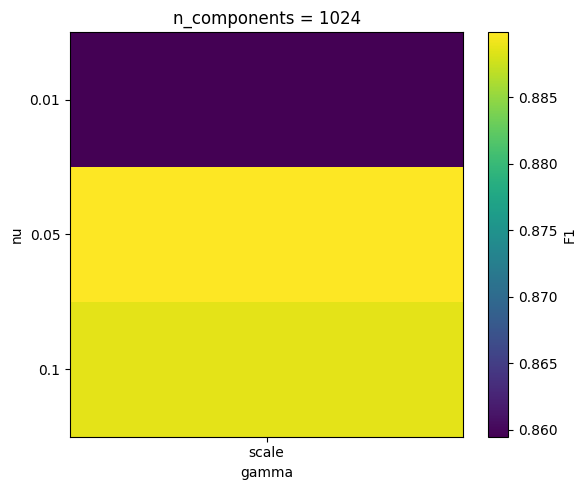

In [12]:
# Visualize the hyperparameter sweep as heatmaps (F1 score vs nu/gamma)
import matplotlib.pyplot as plt

n_components_values = sorted(results_df['n_components'].unique())

fig, axes = plt.subplots(
    1,
    len(n_components_values),
    figsize=(6 * len(n_components_values), 5),
    squeeze=False
)

for ax, n_comp in zip(axes.flat, n_components_values):

    df = results_df[results_df['n_components'] == n_comp]

    pivot = df.pivot_table(
        index='nu',
        columns='gamma',
        values='f1'
    )

    im = ax.imshow(
        pivot,
        aspect='auto',
        cmap='viridis'
    )

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel('gamma')
    ax.set_ylabel('nu')
    ax.set_title(f'n_components = {n_comp}')

    fig.colorbar(im, ax=ax, label='F1')

plt.tight_layout()
plt.show()

In [13]:

from sklearn.svm import OneClassSVM
#best prameters from last part by F1
nu = 0.05
gamma = 'scale'
n_components=1024
pca = PCA(n_components=n_components)
all_data_scaled  = np.concatenate(
  [X_train_feture_norm, X_test_feture_norm, X_test_mod_feture_norm,X_h_a_feture_norm],
  axis=0)
pca.fit(all_data_scaled)
X_train_pca = pca.transform(X_train_feture_norm)
X_test_pca = pca.transform(X_test_feture_norm)
X_test_mod_pca = pca.transform(X_test_mod_feture_norm)
X_h_a_pca = pca.transform(X_h_a_feture_norm)

# Fit the One-Class SVM
clf = OneClassSVM(gamma=gamma, kernel="rbf", nu=nu)
clf.fit(X_train_pca)

OneClassSVM(nu=0.05)

In [14]:
y_pred_human_or_agent = clf.predict(X_h_a_pca)

not_same = y_pred_human_or_agent[y_pred_human_or_agent == -1].size
same = y_pred_human_or_agent[y_pred_human_or_agent == 1].size
# Fraction of human/agent samples classified as "normal"
print(" Fraction of human/agent samples classified as normal=",(same/len(y_pred_human_or_agent)))

 Fraction of human/agent samples classified as normal= 0.9144827586206896


In [15]:
print(y_pred_human_or_agent.shape)

(725,)


In [16]:
# Split the human/agent samples into those flagged as anomalous vs normal,
# for visual inspection below.
X_h_a_anomaly=data_h_a[y_pred_human_or_agent==-1]
X_h_a_normal=data_h_a[y_pred_human_or_agent==1]

In [17]:
"""
Save a random sample of 2D histogram images as individual PNGs, then
stitch them together into a single mosaic image for quick visual
review.
"""

def carate_pics(data,output_dir,size=60,num_cols = 4):
  from PIL import Image
  import math
  x = np.zeros(len(data), dtype=int)
  x[:size] = 1
  np.random.shuffle(x)
  data=data[x==1,:,:]
  print(data.shape)
  os.makedirs(output_dir, exist_ok=True)
  for i, histogram in enumerate(data):
      print(histogram.shape,i)
      fig, ax = plt.subplots(figsize=(8, 6))
      im = ax.imshow(histogram, cmap="grey_r",vmax=1,extent=[0, 1500, 0, 1500])
      #fig.colorbar(im, ax=ax, label="Value")
      fig.tight_layout()
      fig.savefig(
          os.path.join(output_dir, f"image_{i:05d}.png"),
          dpi=150
      )
      plt.close(fig)

  # Create mosaic
  image_files = sorted([
      os.path.join(output_dir, f)
      for f in os.listdir(output_dir)
      if f.endswith(".png") and f.startswith("image_")
  ])
  images = [Image.open(f) for f in image_files]
  n_cols = num_cols
  n_rows = math.ceil(len(images) / n_cols)
  img_width, img_height = images[0].size
  mosaic = Image.new(
      "RGB",
      (n_cols * img_width, n_rows * img_height),
      "white"
  )
  for i, img in enumerate(images):
      row = i // n_cols
      col = i % n_cols
      x = col * img_width
      y = row * img_height
      mosaic.paste(img, (x, y))
  mosaic_path = os.path.join(output_dir, "mosaic.png")
  mosaic.save(mosaic_path)
  print("Mosaic saved to:", mosaic_path)

In [18]:
# Human/agent samples the model flagged as "anomalous" (different from bot
# data) and "normal" (similar to bot data), respectively.
carate_pics(X_h_a_anomaly,r"/kaggle/working/anomaly",size=100,num_cols=4)
carate_pics(X_h_a_normal,r"/kaggle/working/normal",size=100,num_cols=4)

(62, 214, 214)
(214, 214) 0
(214, 214) 1
(214, 214) 2
(214, 214) 3
(214, 214) 4
(214, 214) 5
(214, 214) 6
(214, 214) 7
(214, 214) 8
(214, 214) 9
(214, 214) 10
(214, 214) 11
(214, 214) 12
(214, 214) 13
(214, 214) 14
(214, 214) 15
(214, 214) 16
(214, 214) 17
(214, 214) 18
(214, 214) 19
(214, 214) 20
(214, 214) 21
(214, 214) 22
(214, 214) 23
(214, 214) 24
(214, 214) 25
(214, 214) 26
(214, 214) 27
(214, 214) 28
(214, 214) 29
(214, 214) 30
(214, 214) 31
(214, 214) 32
(214, 214) 33
(214, 214) 34
(214, 214) 35
(214, 214) 36
(214, 214) 37
(214, 214) 38
(214, 214) 39
(214, 214) 40
(214, 214) 41
(214, 214) 42
(214, 214) 43
(214, 214) 44
(214, 214) 45
(214, 214) 46
(214, 214) 47
(214, 214) 48
(214, 214) 49
(214, 214) 50
(214, 214) 51
(214, 214) 52
(214, 214) 53
(214, 214) 54
(214, 214) 55
(214, 214) 56
(214, 214) 57
(214, 214) 58
(214, 214) 59
(214, 214) 60
(214, 214) 61
Mosaic saved to: /kaggle/working/anomaly/mosaic.png
(100, 214, 214)
(214, 214) 0
(214, 214) 1
(214, 214) 2
(214, 214) 3
(214, 2

In [19]:
# A sample of the original bot training data itself, for visual reference.
carate_pics(data,r"/kaggle/working/bot",size=100,num_cols=4)

(100, 214, 214)
(214, 214) 0
(214, 214) 1
(214, 214) 2
(214, 214) 3
(214, 214) 4
(214, 214) 5
(214, 214) 6
(214, 214) 7
(214, 214) 8
(214, 214) 9
(214, 214) 10
(214, 214) 11
(214, 214) 12
(214, 214) 13
(214, 214) 14
(214, 214) 15
(214, 214) 16
(214, 214) 17
(214, 214) 18
(214, 214) 19
(214, 214) 20
(214, 214) 21
(214, 214) 22
(214, 214) 23
(214, 214) 24
(214, 214) 25
(214, 214) 26
(214, 214) 27
(214, 214) 28
(214, 214) 29
(214, 214) 30
(214, 214) 31
(214, 214) 32
(214, 214) 33
(214, 214) 34
(214, 214) 35
(214, 214) 36
(214, 214) 37
(214, 214) 38
(214, 214) 39
(214, 214) 40
(214, 214) 41
(214, 214) 42
(214, 214) 43
(214, 214) 44
(214, 214) 45
(214, 214) 46
(214, 214) 47
(214, 214) 48
(214, 214) 49
(214, 214) 50
(214, 214) 51
(214, 214) 52
(214, 214) 53
(214, 214) 54
(214, 214) 55
(214, 214) 56
(214, 214) 57
(214, 214) 58
(214, 214) 59
(214, 214) 60
(214, 214) 61
(214, 214) 62
(214, 214) 63
(214, 214) 64
(214, 214) 65
(214, 214) 66
(214, 214) 67
(214, 214) 68
(214, 214) 69
(214, 214) 70
